In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [71]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

In [72]:
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (1460, 81)
Testing Dataset Shape: (1459, 80)


In [73]:
train_df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [74]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [75]:
display(train_df.describe())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [76]:
display(train_df.dtypes.value_counts())

object     43
int64      35
float64     3
Name: count, dtype: int64

In [77]:
missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

display(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [78]:
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

display(missing_percentage)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [79]:
missing_analysis = pd.DataFrame({
    "Missing Values": train_df.isnull().sum(),
    "Missing Percentage": (train_df.isnull().sum() / len(train_df)) * 100
})

missing_analysis = missing_analysis[
    missing_analysis["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_analysis)

,Missing Values,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


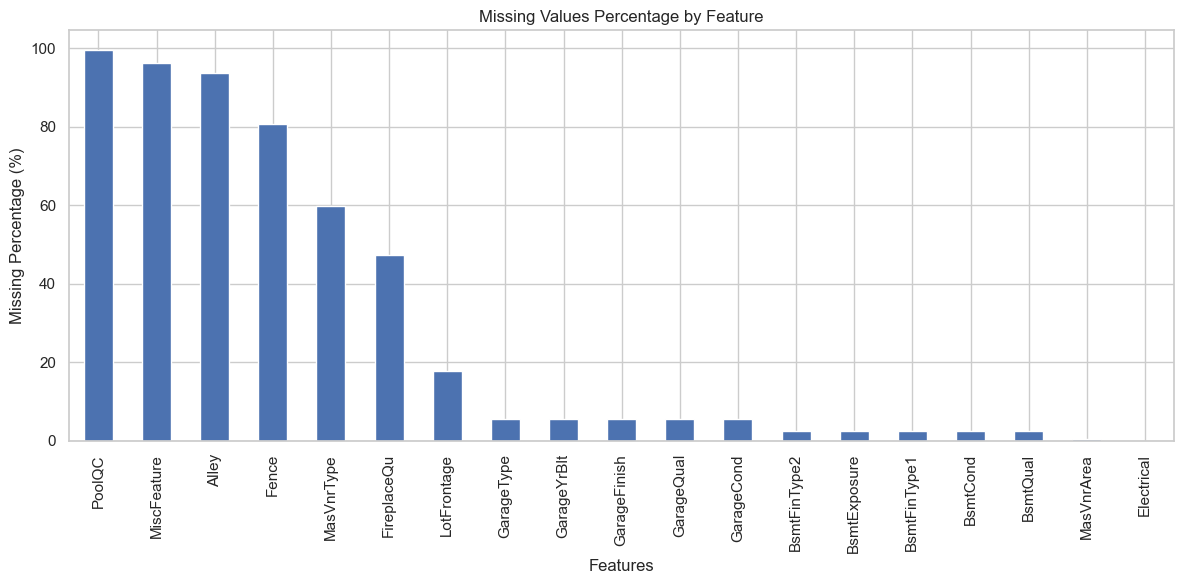

In [80]:
plt.figure(figsize=(12, 6))

missing_percentage.plot(kind="bar")

plt.title("Missing Values Percentage by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [81]:
sale_price_stats = train_df["SalePrice"].describe()

display(sale_price_stats)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [82]:
print("Mean Sale Price:", train_df["SalePrice"].mean())
print("Median Sale Price:", train_df["SalePrice"].median())
print("Minimum Sale Price:", train_df["SalePrice"].min())
print("Maximum Sale Price:", train_df["SalePrice"].max())

Mean Sale Price: 180921.19589041095
Median Sale Price: 163000.0
Minimum Sale Price: 34900
Maximum Sale Price: 755000


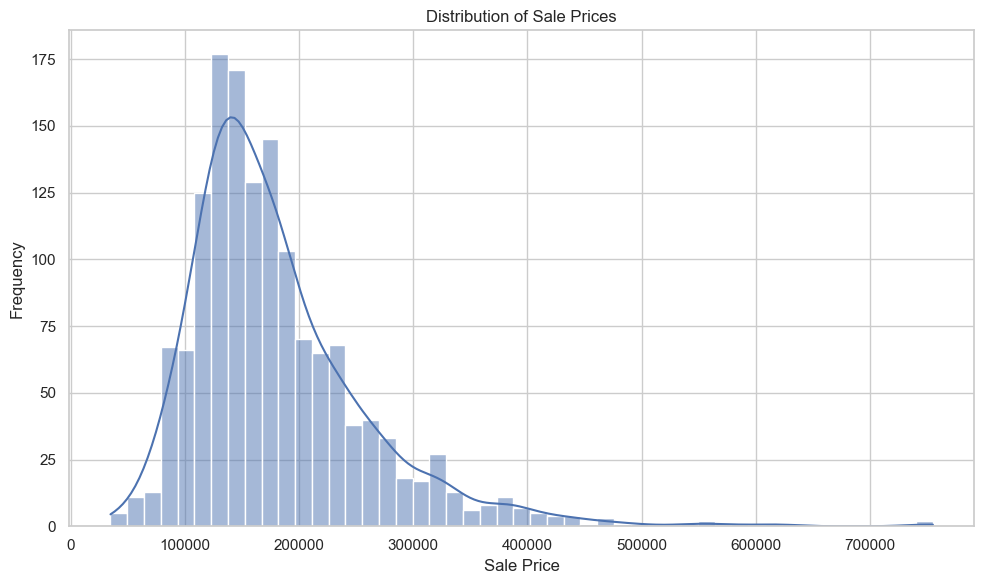

In [83]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train_df["SalePrice"],
    kde=True
)

plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

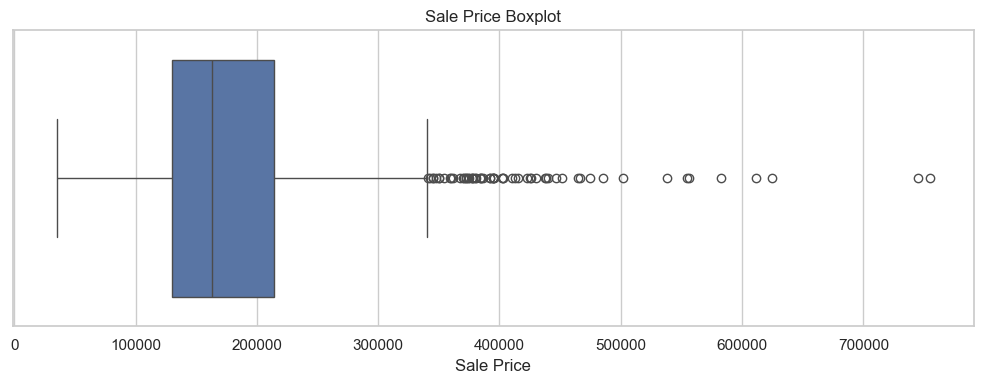

In [84]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=train_df["SalePrice"])

plt.title("Sale Price Boxplot")
plt.xlabel("Sale Price")

plt.tight_layout()
plt.show()

In [85]:
correlation = train_df.corr(numeric_only=True)["SalePrice"].sort_values(
    ascending=False
)

display(correlation)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [86]:
top_correlations = correlation.head(11)

display(top_correlations)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

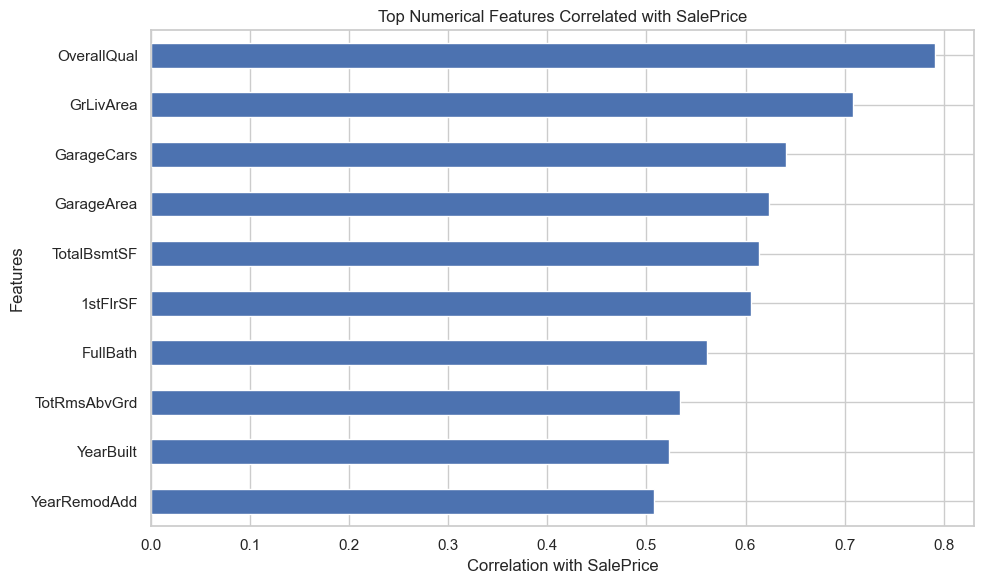

In [87]:
plt.figure(figsize=(10, 6))

top_correlations.drop("SalePrice").sort_values().plot(
    kind="barh"
)

plt.title("Top Numerical Features Correlated with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

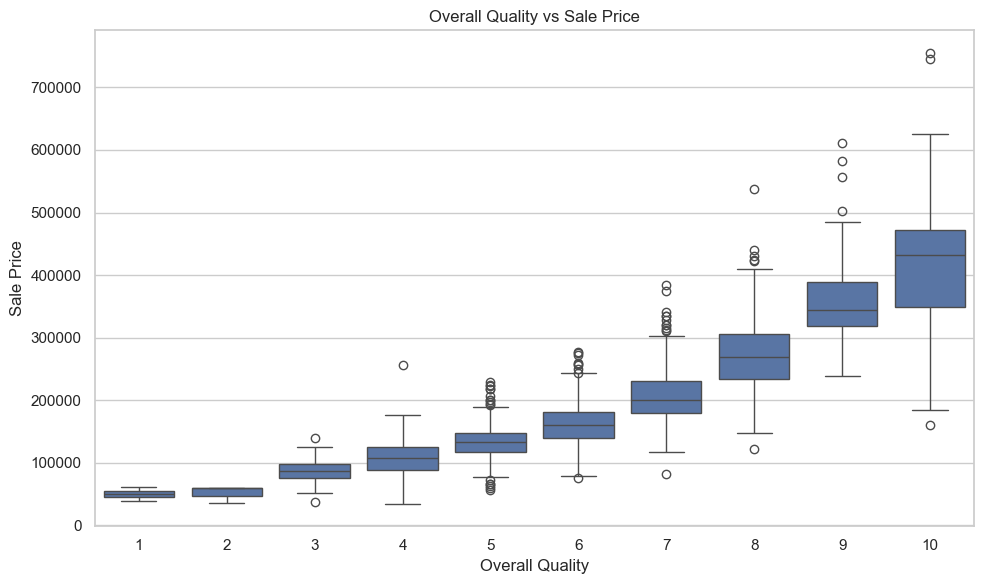

In [88]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=train_df["OverallQual"],
    y=train_df["SalePrice"]
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

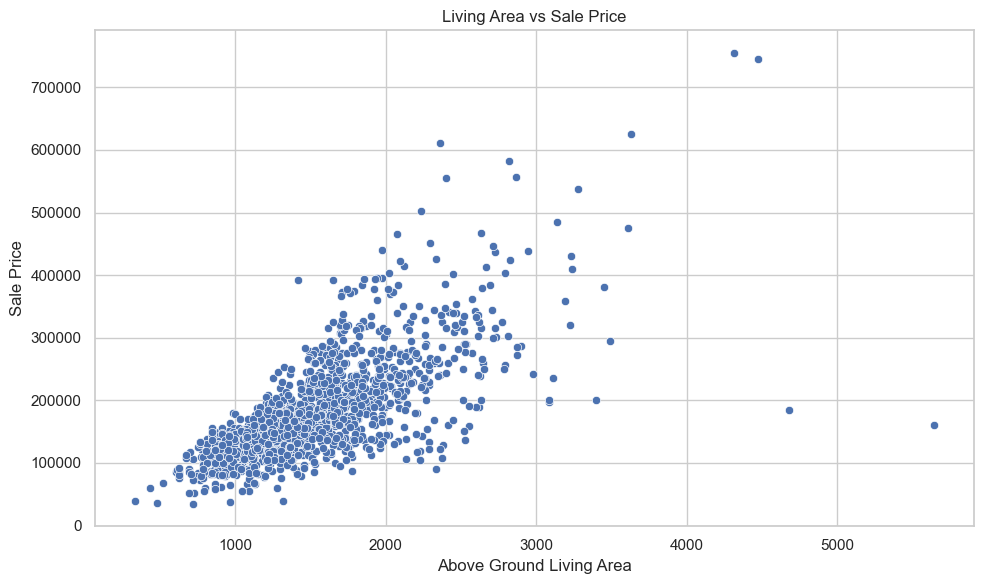

In [89]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

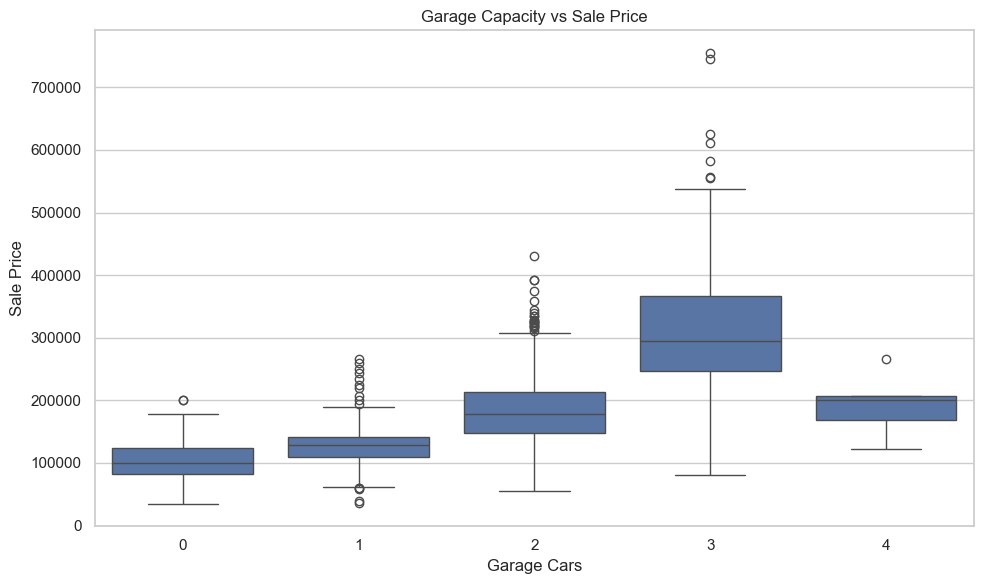

In [90]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=train_df["GarageCars"],
    y=train_df["SalePrice"]
)

plt.title("Garage Capacity vs Sale Price")
plt.xlabel("Garage Cars")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

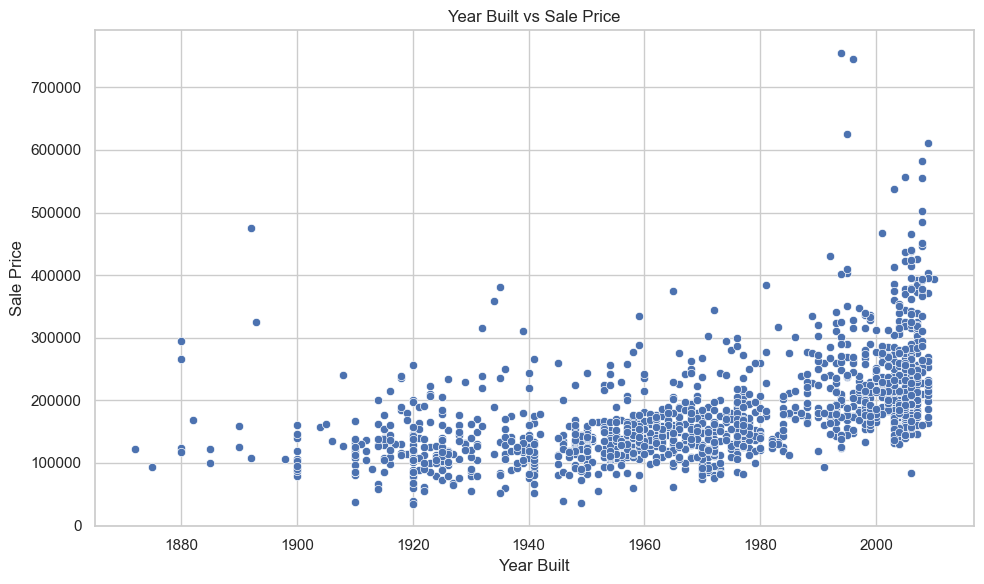

In [91]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="YearBuilt",
    y="SalePrice"
)

plt.title("Year Built vs Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

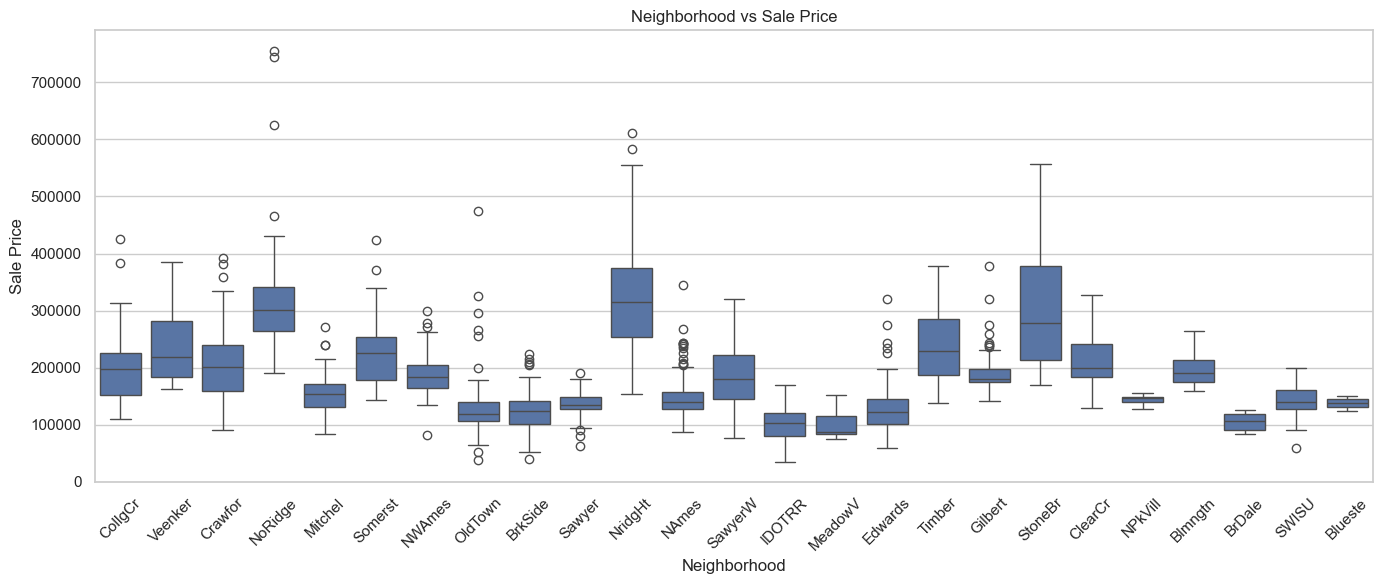

In [92]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=train_df,
    x="Neighborhood",
    y="SalePrice"
)

plt.title("Neighborhood vs Sale Price")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [93]:
neighborhood_prices = (
    train_df.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

display(neighborhood_prices)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

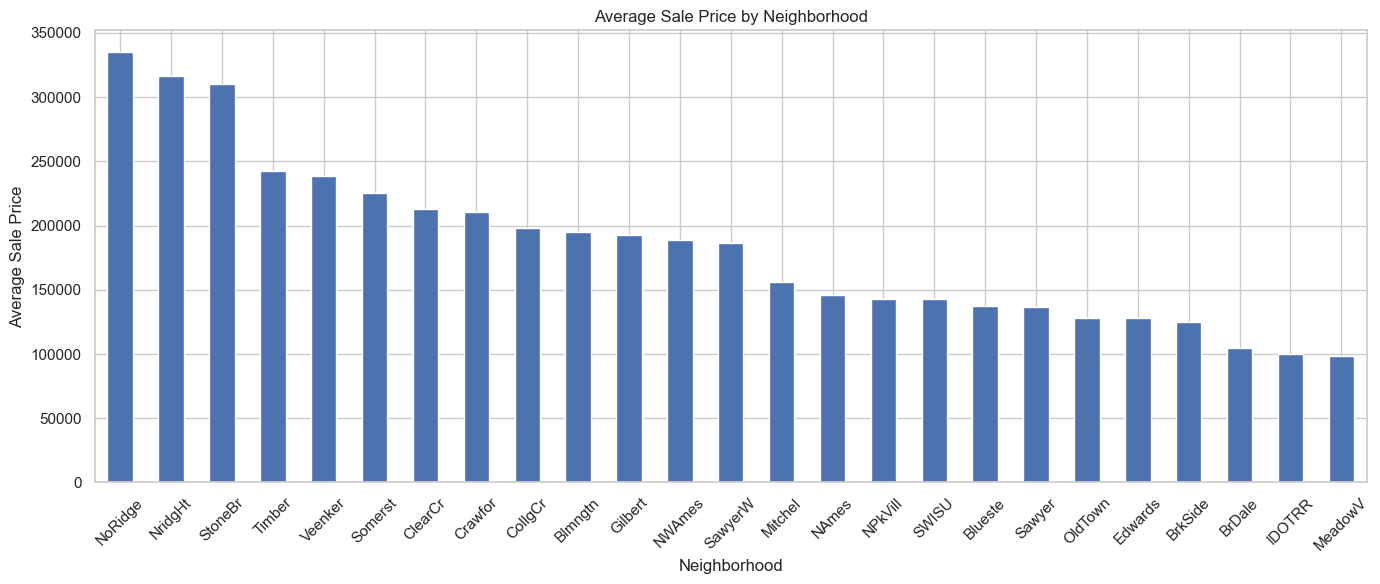

In [94]:
plt.figure(figsize=(14, 6))

neighborhood_prices.plot(kind="bar")

plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
quality_prices = (
    train_df.groupby("OverallQual")["SalePrice"]
    .mean()
)

display(quality_prices)

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

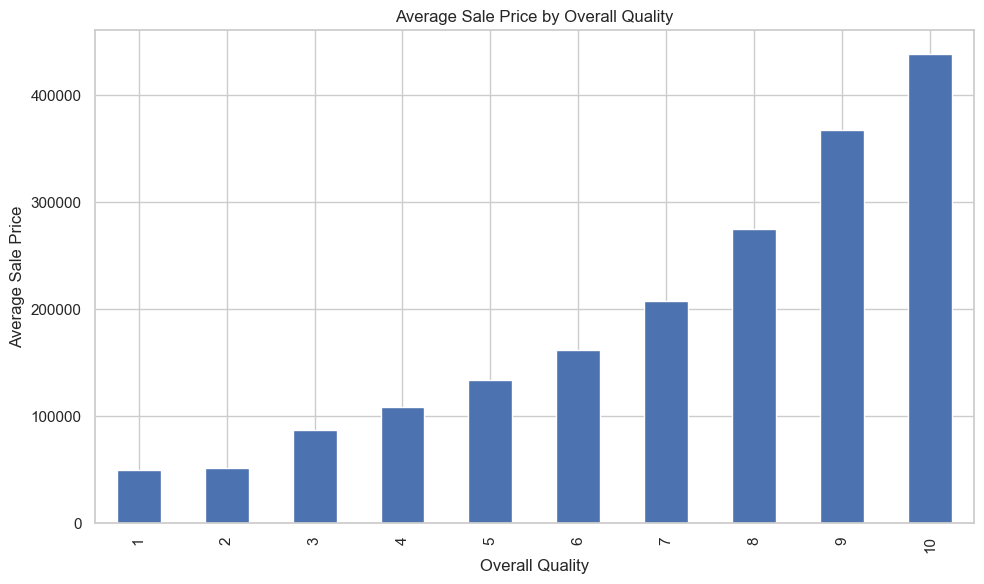

In [96]:
plt.figure(figsize=(10, 6))

quality_prices.plot(kind="bar")

plt.title("Average Sale Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Average Sale Price")

plt.tight_layout()
plt.show()

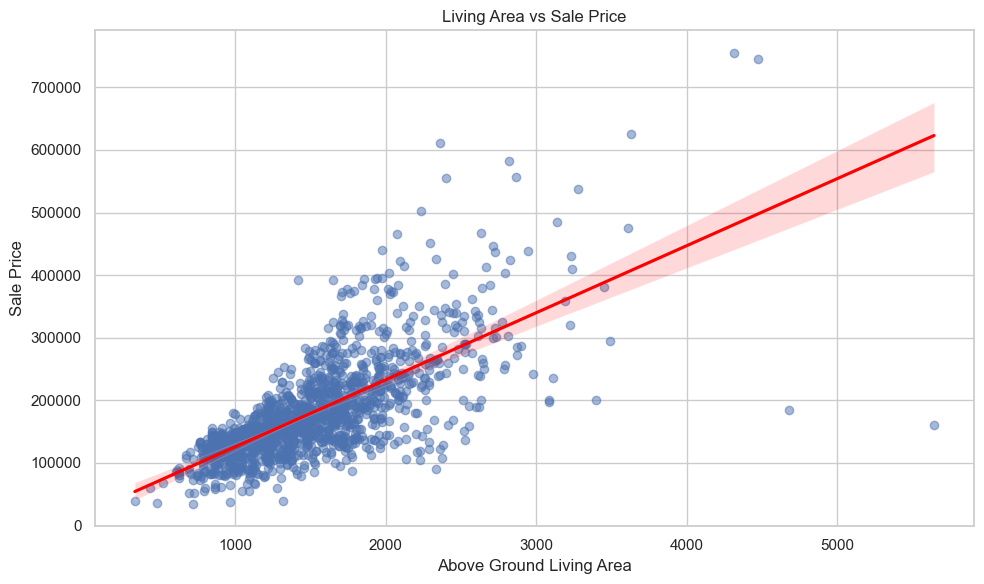

In [97]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=train_df,
    x="GrLivArea",
    y="SalePrice",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

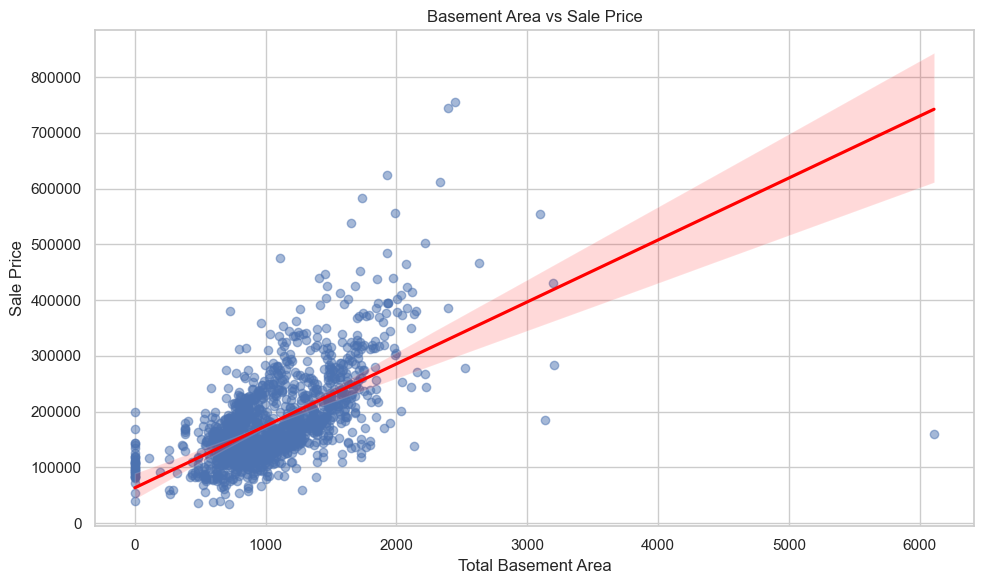

In [98]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=train_df,
    x="TotalBsmtSF",
    y="SalePrice",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Basement Area vs Sale Price")
plt.xlabel("Total Basement Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

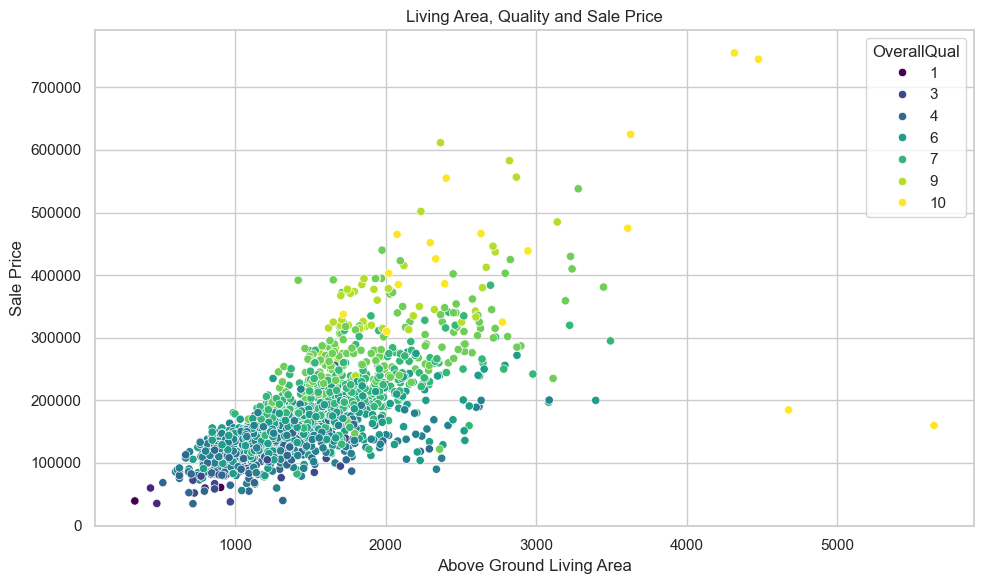

In [99]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    palette="viridis"
)

plt.title("Living Area, Quality and Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

In [100]:
Q1 = train_df["GrLivArea"].quantile(0.25)
Q3 = train_df["GrLivArea"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

grlivarea_outliers = train_df[
    (train_df["GrLivArea"] < lower_bound) |
    (train_df["GrLivArea"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(grlivarea_outliers))

Lower Bound: 158.625
Upper Bound: 2747.625
Number of Outliers: 31


In [101]:
display(
    grlivarea_outliers[
        ["Id", "GrLivArea", "OverallQual", "SalePrice"]
    ].sort_values("GrLivArea", ascending=False)
)

,Id,GrLivArea,OverallQual,SalePrice
1298,1299,5642,10,160000
523,524,4676,10,184750
1182,1183,4476,10,745000
691,692,4316,10,755000
1169,1170,3627,10,625000
185,186,3608,10,475000
304,305,3493,7,295000
1268,1269,3447,8,381000
635,636,3395,6,200000
769,770,3279,8,538000


In [102]:
Q1 = train_df["SalePrice"].quantile(0.25)
Q3 = train_df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

saleprice_outliers = train_df[
    (train_df["SalePrice"] < lower_bound) |
    (train_df["SalePrice"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of SalePrice Outliers:", len(saleprice_outliers))

Lower Bound: 3937.5
Upper Bound: 340037.5
Number of SalePrice Outliers: 61


In [103]:
display(
    saleprice_outliers[
        ["Id", "OverallQual", "GrLivArea", "SalePrice"]
    ].sort_values("SalePrice", ascending=False)
)

,Id,OverallQual,GrLivArea,SalePrice
691,692,10,4316,755000
1182,1183,10,4476,745000
1169,1170,10,3627,625000
898,899,9,2364,611657
803,804,9,2822,582933
...,...,...,...,...
990,991,8,2392,348000
642,643,8,2704,345000
11,12,9,2324,345000
320,321,9,2596,342643


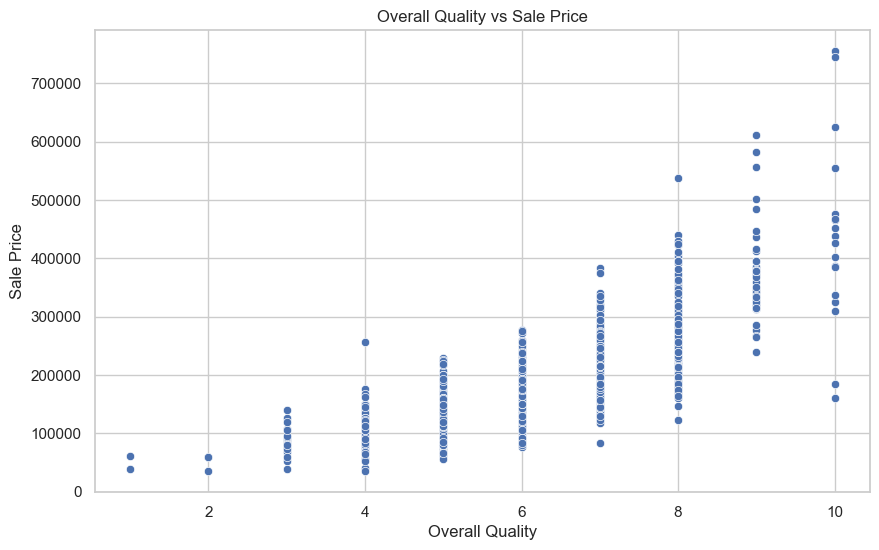

In [104]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.show()

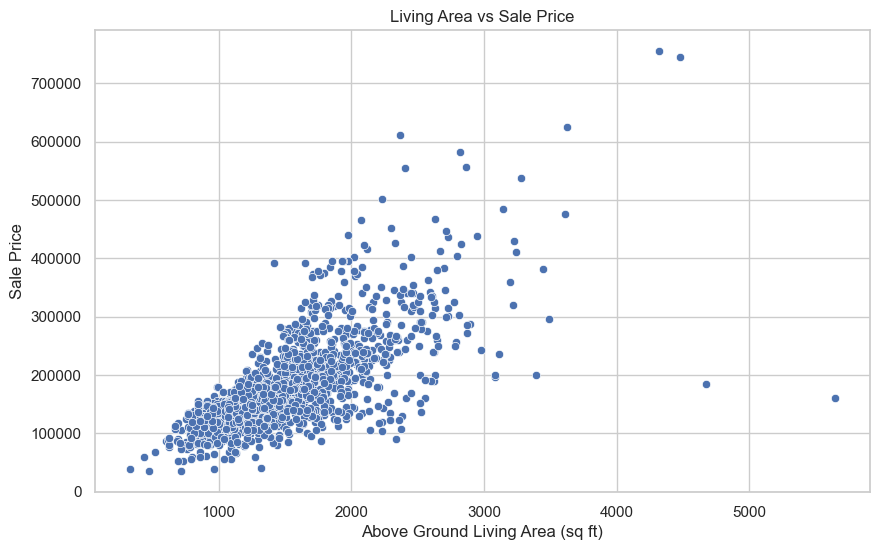

In [105]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.show()

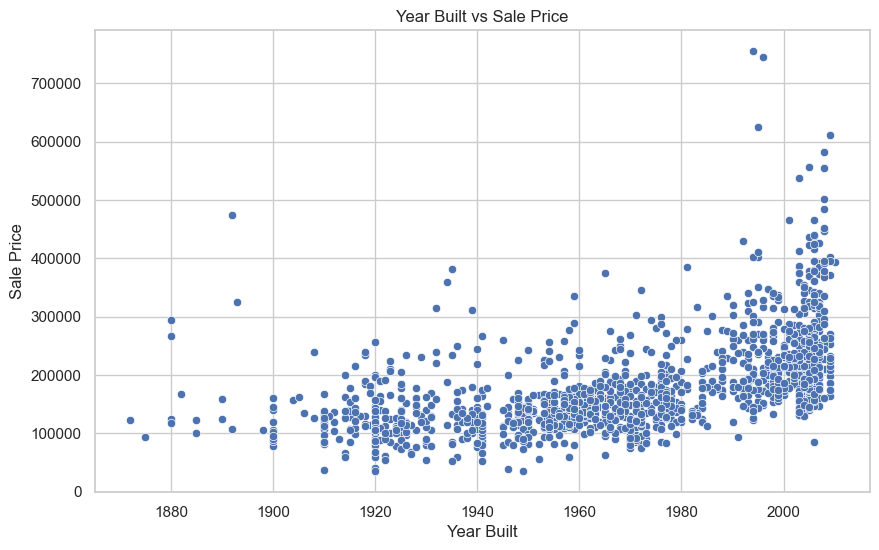

In [106]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df,
    x="YearBuilt",
    y="SalePrice"
)

plt.title("Year Built vs Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")
plt.show()

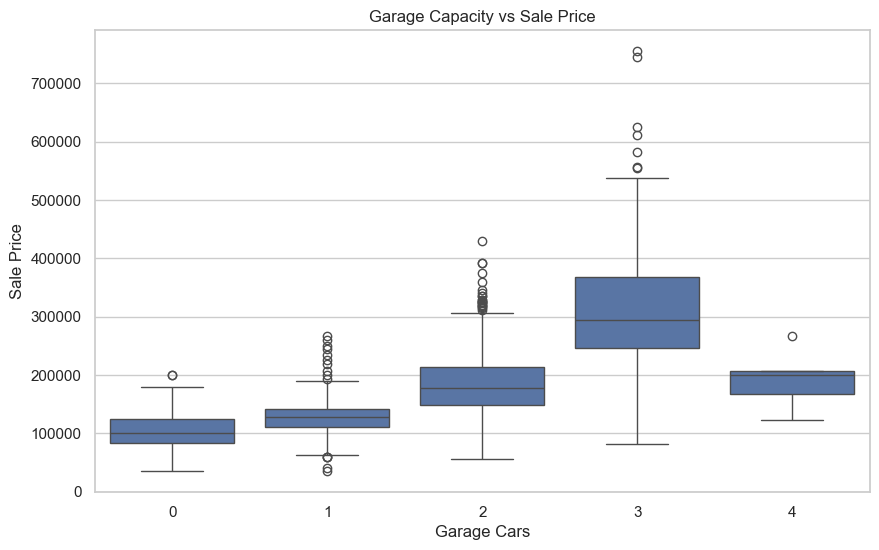

In [107]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x="GarageCars",
    y="SalePrice"
)

plt.title("Garage Capacity vs Sale Price")
plt.xlabel("Garage Cars")
plt.ylabel("Sale Price")
plt.show()

In [108]:
categorical_features = train_df.select_dtypes(include="object").columns

categorical_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Values": [train_df[col].nunique() for col in categorical_features]
})

categorical_summary.sort_values(
    by="Unique Values",
    ascending=False
).head(15)

,Feature,Unique Values
8,Neighborhood,25
16,Exterior2nd,16
15,Exterior1st,15
41,SaleType,9
9,Condition1,9
10,Condition2,8
12,HouseStyle,8
14,RoofMatl,8
31,Functional,7
25,BsmtFinType2,6


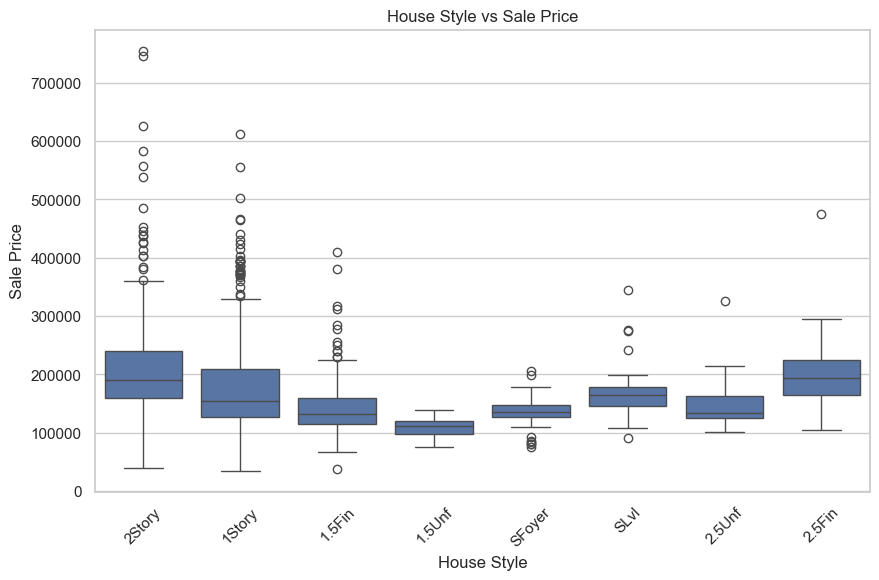

In [109]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x="HouseStyle",
    y="SalePrice"
)

plt.title("House Style vs Sale Price")
plt.xlabel("House Style")
plt.ylabel("Sale Price")
plt.xticks(rotation=45)

plt.show()

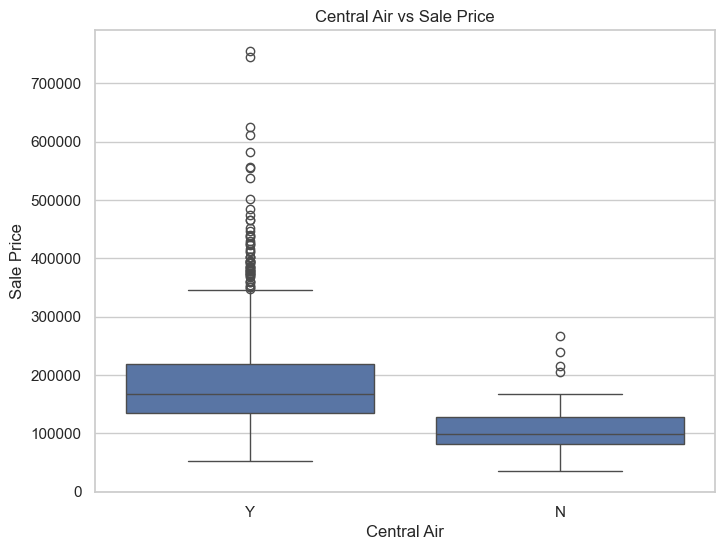

In [110]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=train_df,
    x="CentralAir",
    y="SalePrice"
)

plt.title("Central Air vs Sale Price")
plt.xlabel("Central Air")
plt.ylabel("Sale Price")

plt.show()

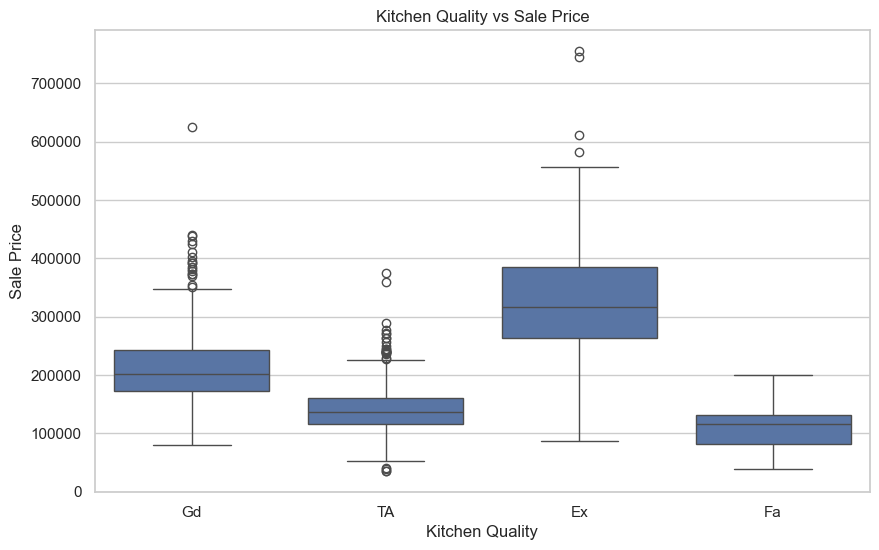

In [111]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x="KitchenQual",
    y="SalePrice"
)

plt.title("Kitchen Quality vs Sale Price")
plt.xlabel("Kitchen Quality")
plt.ylabel("Sale Price")

plt.show()

In [112]:
categorical_features = [
    "ExterQual",
    "KitchenQual",
    "GarageFinish",
    "Foundation",
    "BsmtQual"
]

for feature in categorical_features:

    avg_price = train_df.groupby(feature)["SalePrice"].mean().sort_values(ascending=False)

    print(f"\nAverage Sale Price by {feature}:")
    display(avg_price)


Average Sale Price by ExterQual:


ExterQual
Ex    367360.961538
Gd    231633.510246
TA    144341.313466
Fa     87985.214286
Name: SalePrice, dtype: float64


Average Sale Price by KitchenQual:


KitchenQual
Ex    328554.670000
Gd    212116.023891
TA    139962.511565
Fa    105565.205128
Name: SalePrice, dtype: float64


Average Sale Price by GarageFinish:


GarageFinish
Fin    240052.690341
RFn    202068.869668
Unf    142156.423140
Name: SalePrice, dtype: float64


Average Sale Price by Foundation:


Foundation
PConc     225230.442040
Wood      185666.666667
Stone     165959.166667
CBlock    149805.714511
BrkTil    132291.075342
Slab      107365.625000
Name: SalePrice, dtype: float64


Average Sale Price by BsmtQual:


BsmtQual
Ex    327041.041322
Gd    202688.478964
TA    140759.818182
Fa    115692.028571
Name: SalePrice, dtype: float64

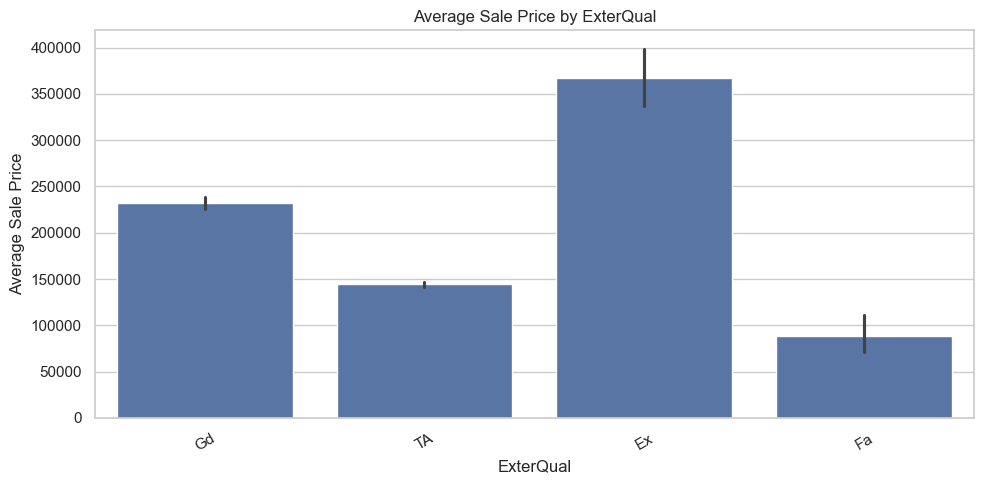

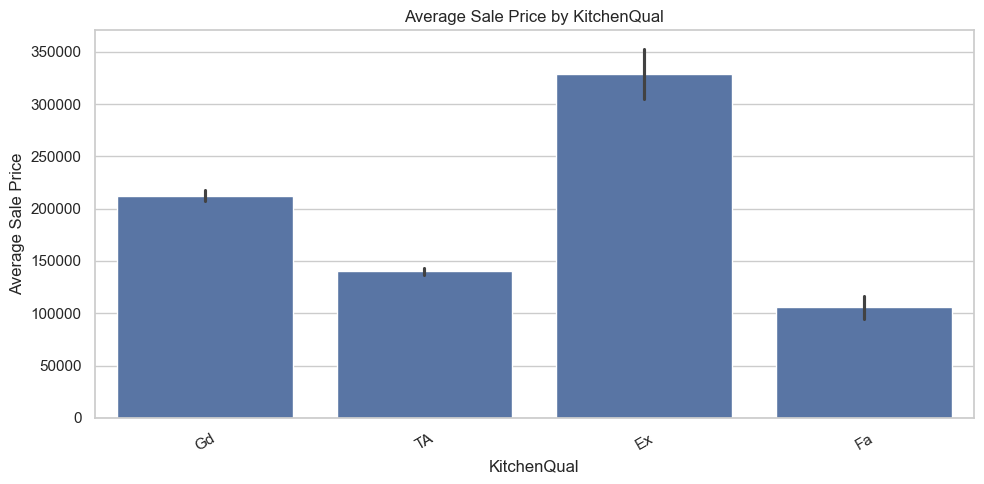

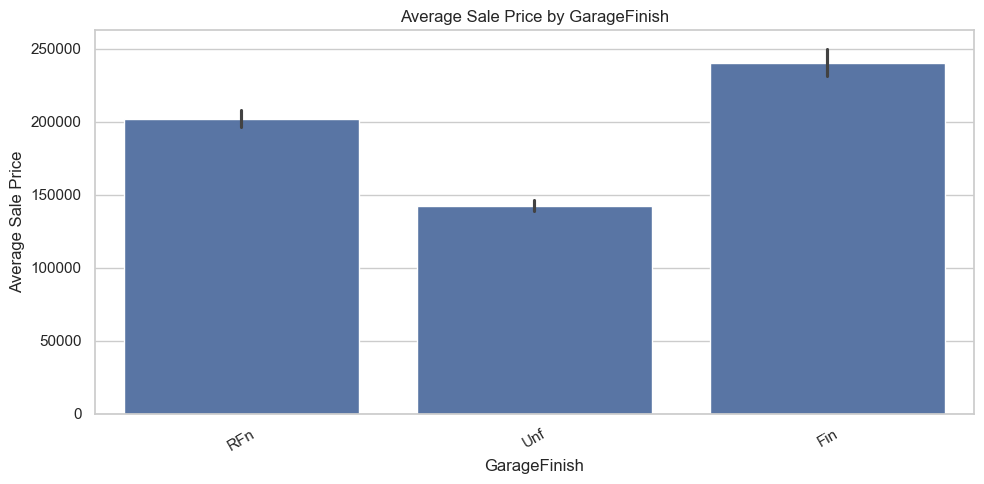

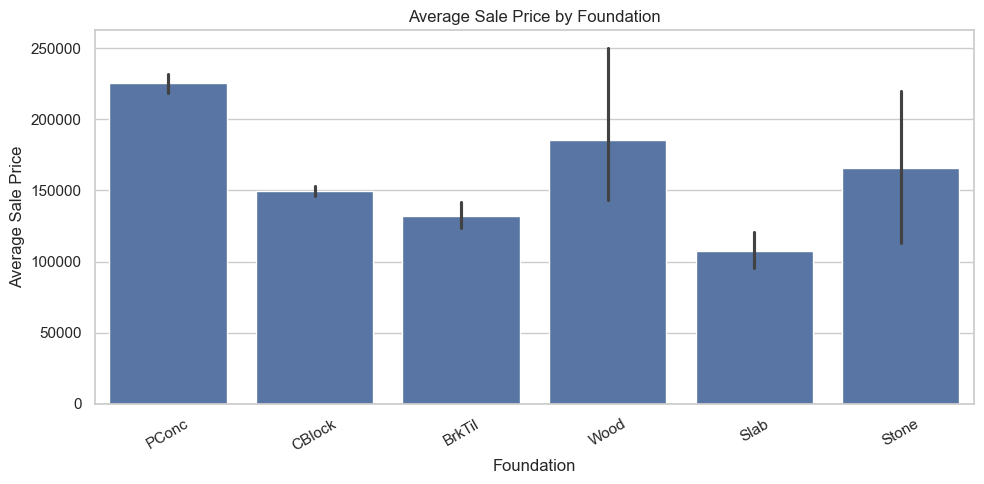

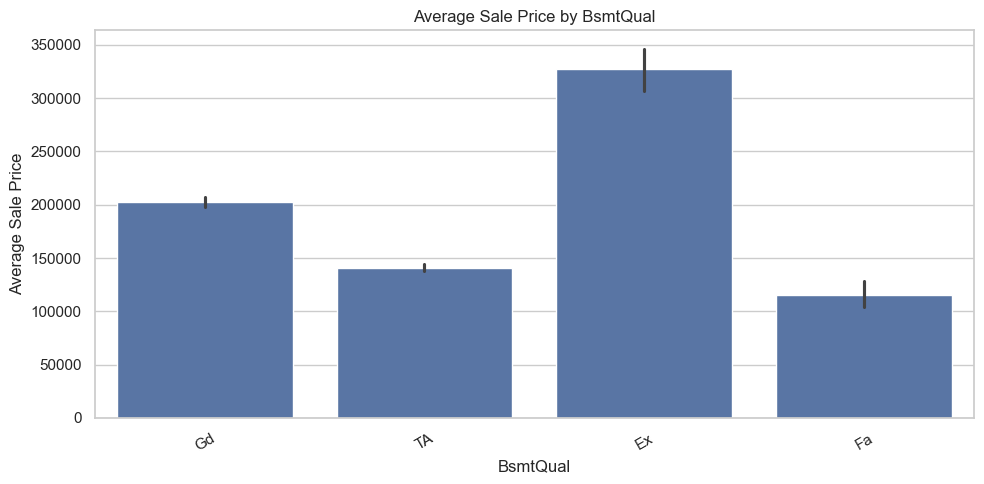

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = [
    "ExterQual",
    "KitchenQual",
    "GarageFinish",
    "Foundation",
    "BsmtQual"
]

for feature in categorical_features:

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=train_df,
        x=feature,
        y="SalePrice",
        estimator="mean"
    )

    plt.title(f"Average Sale Price by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Average Sale Price")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

In [114]:
train_processed = train_df.copy()
test_processed = test_df.copy()

print("Train shape:", train_processed.shape)
print("Test shape:", test_processed.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [115]:
X = train_processed.drop("SalePrice", axis=1)
y = train_processed["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [116]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 37
Number of categorical features: 43


In [117]:
missing_summary = X.isnull().sum()

missing_summary = missing_summary[
    missing_summary > 0
].sort_values(ascending=False)

display(missing_summary)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [118]:
none_columns = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtFinType2",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtCond",
    "BsmtQual"
]

for col in none_columns:
    X[col] = X[col].fillna("None")

print("Categorical missing values handled.")

Categorical missing values handled.


In [119]:
zero_columns = [
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_columns:
    X[col] = X[col].fillna(0)

print("Numerical missing values handled.")

Numerical missing values handled.


In [120]:
X["LotFrontage"] = X["LotFrontage"].fillna(
    X["LotFrontage"].median()
)

In [121]:
X["Electrical"] = X["Electrical"].fillna(
    X["Electrical"].mode()[0]
)

In [122]:
missing_after = X.isnull().sum()

missing_after = missing_after[
    missing_after > 0
].sort_values(ascending=False)

display(missing_after)

Series([], dtype: int64)

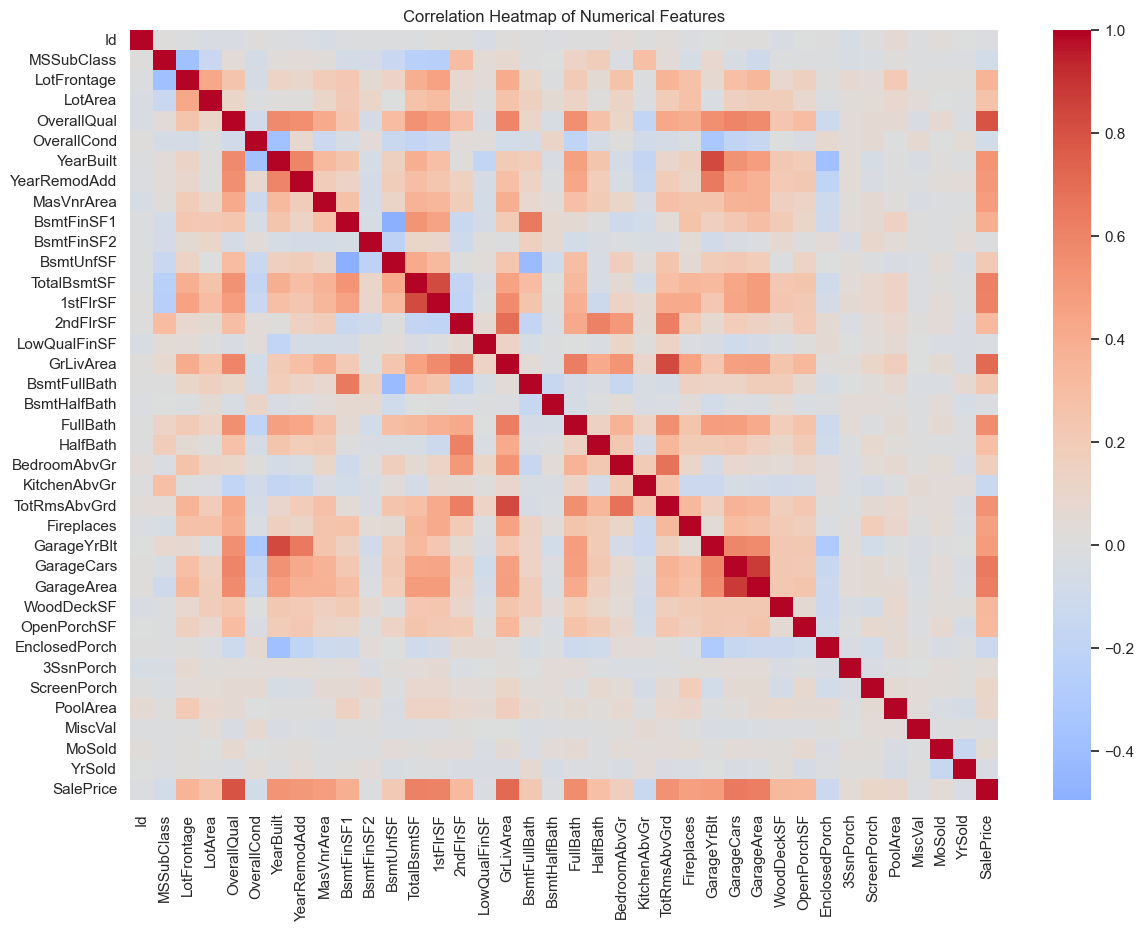

In [123]:
plt.figure(figsize=(14,10))

corr_matrix = train_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

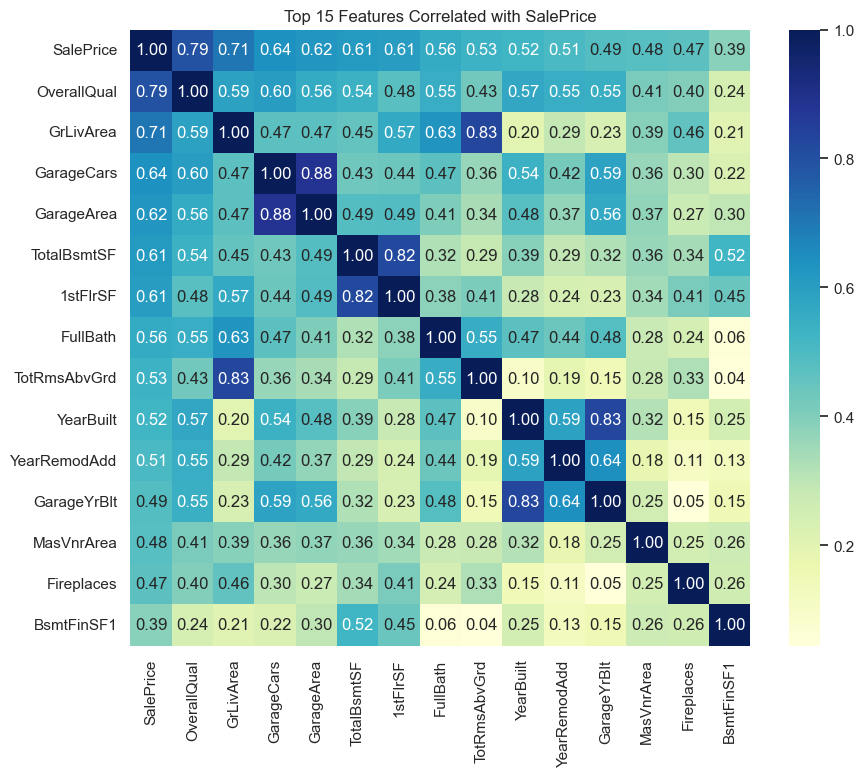

In [124]:
top_features = corr_matrix["SalePrice"].abs().sort_values(
    ascending=False
).head(15).index

plt.figure(figsize=(10,8))

sns.heatmap(
    train_df[top_features].corr(),
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Top 15 Features Correlated with SalePrice")
plt.show()

In [ ]:
processed_train = X.copy()
processed_train["SalePrice"] = y
processed_train.to_csv(
    "data/Analyse_Dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

NameError: name 'X' is not defined